In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (71396, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

     

In [ ]:
fraud_percentage = df['Class'].value_counts(normalize=True) * 100
print("\nFraud Percentage:")
print(fraud_percentage)


Fraud Percentage:
Class
0.0    99.752083
1.0     0.247917
Name: proportion, dtype: float64


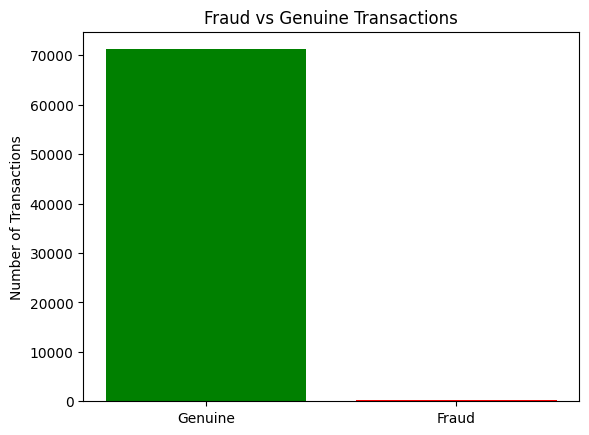

In [ ]:
# Plot
plt.bar(counts.index, counts.values, color=['green', 'red'])
plt.title("Fraud vs Genuine Transactions")
plt.ylabel("Number of Transactions")
plt.show()

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
# Extract Hour from Time
df['Hour'] = (df['Time'] // 3600) % 24

# Night Transaction Flag
df['Night_Transaction'] = np.where(df['Hour'] < 6, 1, 0)

# Log transform Amount
df['Log_Amount'] = np.log1p(df['Amount'])

# High Amount Flag (Top 5%)
threshold = df['Amount'].quantile(0.95)
df['High_Amount_Flag'] = np.where(df['Amount'] > threshold, 1, 0)

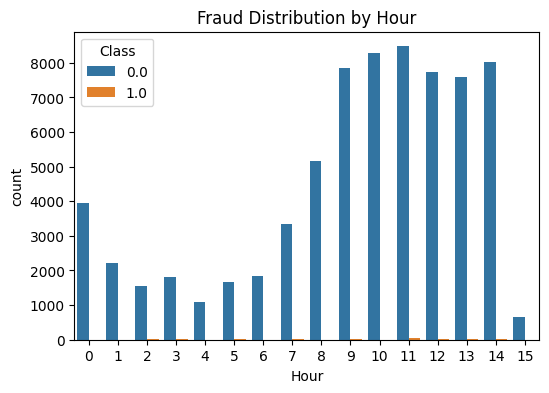

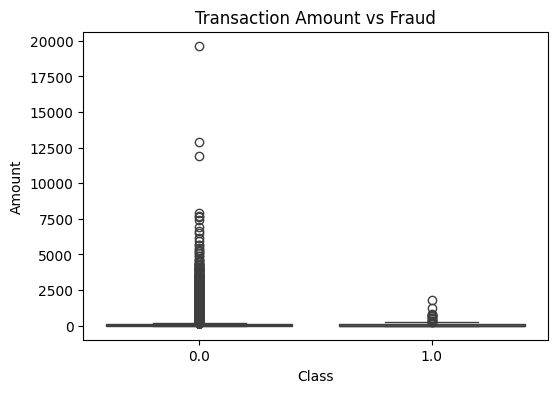

In [ ]:
# Fraud by Hour
plt.figure(figsize=(6,4))
sns.countplot(x='Hour', hue='Class', data=df)
plt.title("Fraud Distribution by Hour")
plt.show()

# Fraud vs Amount
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

In [ ]:
df.drop(['Time'], axis=1, inplace=True)

In [ ]:
scaler = StandardScaler()
df[['Amount', 'Log_Amount']] = scaler.fit_transform(df[['Amount', 'Log_Amount']])

In [ ]:
print("Dataset Shape:", df.shape)

# Drop rows where Class is NaN
df = df.dropna(subset=['Class'])

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dataset Shape: (71396, 34)


In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

sm = SMOTE(k_neighbors=1, random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
Class
0.0    56974
1.0      142
Name: count, dtype: int64

After SMOTE:
Class
0.0    56974
1.0    56974
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("===== Logistic Regression =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

===== Logistic Regression =====
Confusion Matrix:
 [[13892   352]
 [    3    32]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     14244
         1.0       0.08      0.91      0.15        35

    accuracy                           0.98     14279
   macro avg       0.54      0.94      0.57     14279
weighted avg       1.00      0.98      0.99     14279

ROC-AUC Score: 0.9684197857744614


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n===== Random Forest =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


===== Random Forest =====
Confusion Matrix:
 [[14241     3]
 [    3    32]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14244
         1.0       0.91      0.91      0.91        35

    accuracy                           1.00     14279
   macro avg       0.96      0.96      0.96     14279
weighted avg       1.00      1.00      1.00     14279

ROC-AUC Score: 0.9688039074096361


In [ ]:
svm = SVC(probability=True)
svm.fit(X_train_sm, y_train_sm)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

print("\n===== SVM =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_svm))


===== SVM =====
Confusion Matrix:
 [[14175    69]
 [    3    32]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14244
         1.0       0.32      0.91      0.47        35

    accuracy                           0.99     14279
   macro avg       0.66      0.95      0.73     14279
weighted avg       1.00      0.99      1.00     14279

ROC-AUC Score: 0.9547257993340553


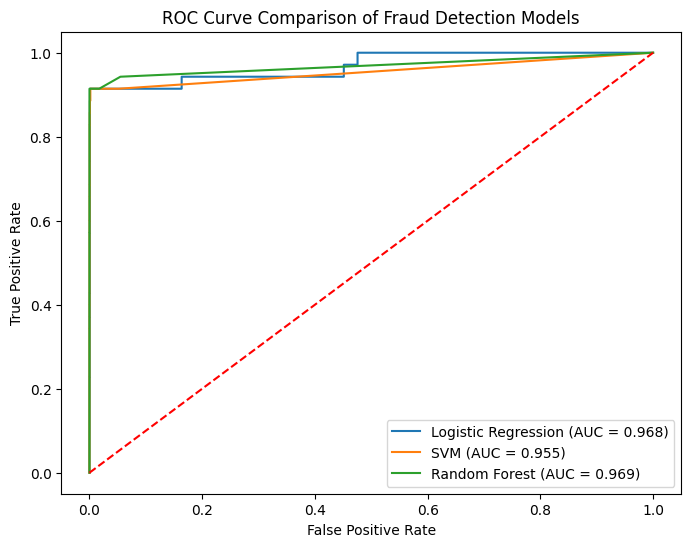

In [ ]:
plt.figure(figsize=(8,6))

# Logistic Regression
y_prob_lr = lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', color='#1f77b4')

# SVM
y_prob_svm = svm.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_prob_svm):.3f})', color='#ff7f0e')

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='#2ca02c')

# Diagonal line for random guessing
plt.plot([0,1], [0,1], linestyle='--', color='red')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Fraud Detection Models')
plt.legend()
plt.show()

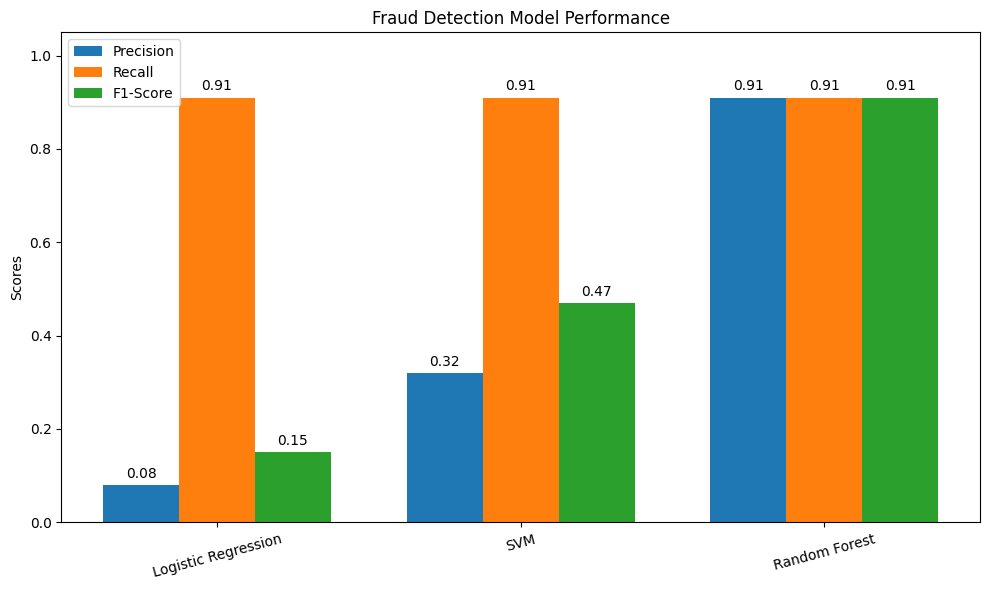

In [ ]:
# Models
models = ['Logistic Regression', 'SVM', 'Random Forest']

# Metrics from your results
precision = [0.08, 0.32, 0.91]
recall = [0.91, 0.91, 0.91]
f1_score = [0.15, 0.47, 0.91]

x = np.arange(len(models))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
rects2 = ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2ca02c')

# Labels and titles
ax.set_ylabel('Scores')
ax.set_ylim(0,1.05)
ax.set_title('Fraud Detection Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

# Add value labels on bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_labels(rects1)
add_labels(rects2)
add_labels(rects3)

plt.tight_layout()
plt.show()